In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""esm1b_llr""","""#FF7043""","""ESM1b""",-1
"""missense""","""cpt1_llr""","""#D84315""","""CPT-1""",1
"""missense""","""revel_score""","""#E53935""","""REVEL""",1
…,…,…,…,…
"""regulatory""","""fz_all_mean""","""#1f77b4""","""Flashzoi mean across RNA (all)""",1
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1


In [ ]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('ted_domain') == False),
        # (pl.col('mobi_curated_disorder_priority') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose regulatory region
        # (pl.col('pangolin_score') < 0.2), # Remove splice variants from the regulatory analysis
        # (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)


selected_categories = ['missense'] # missense
# selected_categories = ['splicing'] # splicing

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

[===========================================================>] Completed 6,991,974,519 of 6,991,974,519 bytes (100%) /home/dnanexus/data_dir/annotations_with_all.parquett


/tmp/ipykernel_43873/3144238911.py:66: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ColumnNotFoundError: unable to find column "mobi_lip_full"; valid columns: ["id", "chrom", "pos", "ref", "alt", "region", "sift", "polyphen", "cadd_phred", "cadd_raw", "am_pathogenicity", "spliceai_pred", "loftee_hc", "loftee_lc", "relative_cds_position", "next_in_frame_relative", "spliceai_delta_score", "pangolin_score", "delta_score", "absplice_dna_max", "absplice2_max", "five_prime_utr_variant_consequence_uaug_gained", "five_prime_utr_variant_consequence_uaug_lost", "five_prime_utr_variant_consequence_uframeshift", "five_prime_utr_variant_consequence_ustop_gained", "five_prime_utr_variant_consequence_ustop_lost", "variant_length", "gpn_score", "promoterai", "score_pai3d", "abexp_abs_max", "gene_length", "dist_to_tss", "aparent2", "cdspos", "cpg", "dst2splice", "esmscoreframeshift", "esmscoreinframe", "esmscoremissense", "gc", "gerpn", "gerps", "grantham", "remapoverlapcl", "remapoverlaptf", "roulette-ar", "roulette-mr", "zoopriphylop", "zoouce", "zooverphylop", "bstatistic", "cdnapo

In [ ]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_278938/2928459309.py:27: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr12:112193191:T:C""","""ENSG00000173064""","""am_pathogenicity""",1
"""chr1:247424951:T:C""","""ENSG00000162711""","""am_pathogenicity""",1
"""chr7:838977:G:A""","""ENSG00000164828""","""am_pathogenicity""",1
"""chr2:178707673:G:A""","""ENSG00000155657""","""am_pathogenicity""",1
"""chr19:16067706:G:A""","""ENSG00000167460""","""am_pathogenicity""",1


In [ ]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_278938/1598827054.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr14:67755207:T:A""","""ENSG00000072121""","""score_pai3d""",0.71149,"""missense""",1,40867.0
"""chr1:186076550:C:T""","""ENSG00000143341""","""score_pai3d""",0.812216,"""missense""",1,19436.0
"""chr8:47785293:G:A""","""ENSG00000253729""","""score_pai3d""",0.246317,"""missense""",1,152132.0
"""chr11:11942909:A:G""","""ENSG00000170242""","""score_pai3d""",0.768133,"""missense""",1,28318.0
"""chr14:67809288:T:C""","""ENSG00000072121""","""score_pai3d""",0.39744,"""missense""",1,119112.0
…,…,…,…,…,…,…
"""chr7:90604241:T:C""","""ENSG00000058091""","""score_pai3d""",0.336647,"""missense""",1,133735.0
"""chr11:57599996:G:A""","""ENSG00000149131""","""score_pai3d""",0.218657,"""missense""",1,156256.0
"""chr20:35652823:C:T""","""ENSG00000244462""","""score_pai3d""",0.418318,"""missense""",1,113900.0


In [ ]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [ ]:
pheno_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:178571014:C:T""","""leg_fatfree_mass_left_int""",-0.04929,7
"""chr17:50187944:C:T""","""basal_metabolic_rate_int""",0.992802,3
"""chr2:178741274:T:C""","""seated_height_int""",0.461834,9
"""chr15:58893289:C:A""","""arm_fat_mass_right_int""",0.632569,1
"""chr2:203125973:G:C""","""seated_height_int""",0.39507,12


## Average z-score by annotation rank (sliding window)

In [ ]:
# Sliding window and bootstrap parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)
n_boot = 1000         # Number of bootstrap resamples across regions
max_num_variants = None  # Maximum number of top-ranked variants per annotation (None = no limit)

In [ ]:
# --- Join variant z-scores with annotation ranks, then bootstrap sliding window ---

id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with pheno whitelist
# Direction-correct mean_pheno_value: if loftee_corr_dir == -1, flip the z-score
# so that "deleterious" variants always have positive z-scores
variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

half_w = window_size // 2

# Join z-scores with annotation ranks, sort by rank
ranked_zscores = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(
        row_pos = pl.col('annotation').cum_count().over('annotation'),
    )
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .collect(engine='streaming')
)

# Map regions to integer indices for fast bootstrap resampling
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
region_idx_map = pl.DataFrame({'region': all_regions, '_region_idx': np.arange(n_regions, dtype=np.int32)})
ranked_zscores = ranked_zscores.join(region_idx_map, on='region', how='left')

annotations_list = sorted(ranked_zscores['annotation'].unique().to_list())


def sliding_window_means(zscores, bc_indices, half_w, weights=None):
    """Sliding window mean at bin centers using prefix sums.
    Window at center c covers [c - half_w, c + half_w) = window_size elements.
    If weights provided, computes weighted mean: sum(z*w) / sum(w).
    """
    if weights is not None:
        wz = zscores * weights
        csum_wz = np.empty(len(wz) + 1, dtype=np.float64)
        csum_wz[0] = 0
        np.cumsum(wz, out=csum_wz[1:])
        csum_w = np.empty(len(weights) + 1, dtype=np.float64)
        csum_w[0] = 0
        np.cumsum(weights, out=csum_w[1:])
        num = csum_wz[bc_indices + half_w] - csum_wz[bc_indices - half_w]
        den = csum_w[bc_indices + half_w] - csum_w[bc_indices - half_w]
        with np.errstate(divide='ignore', invalid='ignore'):
            return np.where(den > 0, num / den, np.nan)
    else:
        csum = np.empty(len(zscores) + 1, dtype=np.float64)
        csum[0] = 0
        np.cumsum(zscores, out=csum[1:])
        return (csum[bc_indices + half_w] - csum[bc_indices - half_w]) / (2 * half_w)


# --- Prepare per-annotation sorted arrays and bin centers ---
anno_arrays = {}
for annotation in tqdm(annotations_list, desc='Preparing arrays'):
    adf = ranked_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)

    # Bin centers (0-indexed) where a full window fits, sampled every step_size
    bc_indices = np.arange(half_w, N - half_w + 1, step_size)

    anno_arrays[annotation] = {
        'zscores': z,
        'region_idx': r_idx,
        'bc_indices': bc_indices,
        'bin_centers': bc_indices.astype(np.float64),
    }

# --- Point estimates (unweighted sliding window mean) ---
point_means = {}
for annotation in annotations_list:
    d = anno_arrays[annotation]
    point_means[annotation] = sliding_window_means(d['zscores'], d['bc_indices'], half_w)

# --- Bootstrap CIs across regions ---
rng = np.random.default_rng(42)
boot_means = {ann: np.full((n_boot, len(anno_arrays[ann]['bc_indices'])), np.nan)
              for ann in annotations_list}

for b in tqdm(range(n_boot), desc='Bootstrapping'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions).astype(np.float64)

    for annotation in annotations_list:
        d = anno_arrays[annotation]
        variant_weights = region_weights[d['region_idx']]
        boot_means[annotation][b] = sliding_window_means(
            d['zscores'], d['bc_indices'], half_w, weights=variant_weights
        )

# --- Build output DataFrame ---
all_results = []
for annotation in annotations_list:
    d = anno_arrays[annotation]
    bm = boot_means[annotation]

    all_results.append(pl.DataFrame({
        'annotation': annotation,
        'bin_center': d['bin_centers'],
        'mean_zscore': point_means[annotation].astype(np.float32),
        'se_zscore': np.nanstd(bm, axis=0).astype(np.float32),
        'ci_lower': np.nanpercentile(bm, 2.5, axis=0).astype(np.float32),
        'ci_upper': np.nanpercentile(bm, 97.5, axis=0).astype(np.float32),
    }))

zscore_binned = pl.concat(all_results).sort(['annotation', 'bin_center'])

print(f"Sliding window results: {zscore_binned.shape[0]} points across {zscore_binned['annotation'].n_unique()} annotations")
zscore_binned

Variant z-scores: 231188 variant-gene pairs


Bootstrapping: 100%|██████████| 1000/1000 [00:13<00:00, 72.35it/s]


Sliding window results: 57113 points across 3 annotations


annotation,bin_center,mean_zscore,se_zscore,ci_lower,ci_upper
str,f64,f32,f32,f32,f32
"""am_pathogenicity""",500.0,0.240027,0.04466,0.158162,0.333736
"""am_pathogenicity""",510.0,0.241576,0.044615,0.159276,0.335247
"""am_pathogenicity""",520.0,0.245157,0.044939,0.162133,0.337003
"""am_pathogenicity""",530.0,0.241927,0.044765,0.160264,0.33569
"""am_pathogenicity""",540.0,0.239031,0.044253,0.156769,0.329622
…,…,…,…,…,…
"""score_pai3d""",146240.0,0.039894,0.026628,-0.013331,0.093327
"""score_pai3d""",146250.0,0.037603,0.026123,-0.01352,0.091426
"""score_pai3d""",146260.0,0.03651,0.025968,-0.014591,0.088454


## Plotting

In [ ]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_center = pl.col('bin_center').log10(),
        log_bin_center_inv = (1 / pl.col('bin_center')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_center')
)

plt_df

annotation,bin_center,mean_zscore,se_zscore,ci_lower,ci_upper,log_bin_center,log_bin_center_inv,color,label,category
str,f64,f32,f32,f32,f32,f64,f64,str,str,str
"""am_pathogenicity""",500.0,0.240027,0.04466,0.158162,0.333736,2.69897,-2.69897,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",500.0,0.271474,0.042293,0.192273,0.356797,2.69897,-2.69897,"""#FB8C00""","""ESM1v""","""missense"""
"""score_pai3d""",500.0,0.276242,0.057848,0.178195,0.402089,2.69897,-2.69897,"""#D84315""","""PrimateAI-3D""","""missense"""
"""am_pathogenicity""",510.0,0.241576,0.044615,0.159276,0.335247,2.70757,-2.70757,"""#FFCA28""","""AlphaMissense""","""missense"""
"""esmscoremissense""",510.0,0.272387,0.04181,0.194266,0.356738,2.70757,-2.70757,"""#FB8C00""","""ESM1v""","""missense"""
…,…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",230600.0,-0.007197,0.02752,-0.06259,0.043323,5.362859,-5.362859,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",230610.0,-0.015557,0.027965,-0.072896,0.036366,5.362878,-5.362878,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",230620.0,-0.017934,0.028006,-0.076705,0.035682,5.362897,-5.362897,"""#FB8C00""","""ESM1v""","""missense"""


In [ ]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_se_lower = mean_zscore - 1.96 * se_zscore
ci_se_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'log_bin_center_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_se_lower': ci_se_lower,
    'ci_se_upper': ci_se_upper
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore'), size=1),
    geom_errorbar(loftee_point_df, aes(x='log_bin_center_inv', ymin='ci_se_lower', ymax='ci_se_upper'), width=0.01),
    geom_text(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore', label='label'), nudge_x=+0.05, size=12, ha='left'),
]

/tmp/ipykernel_278938/1035766839.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


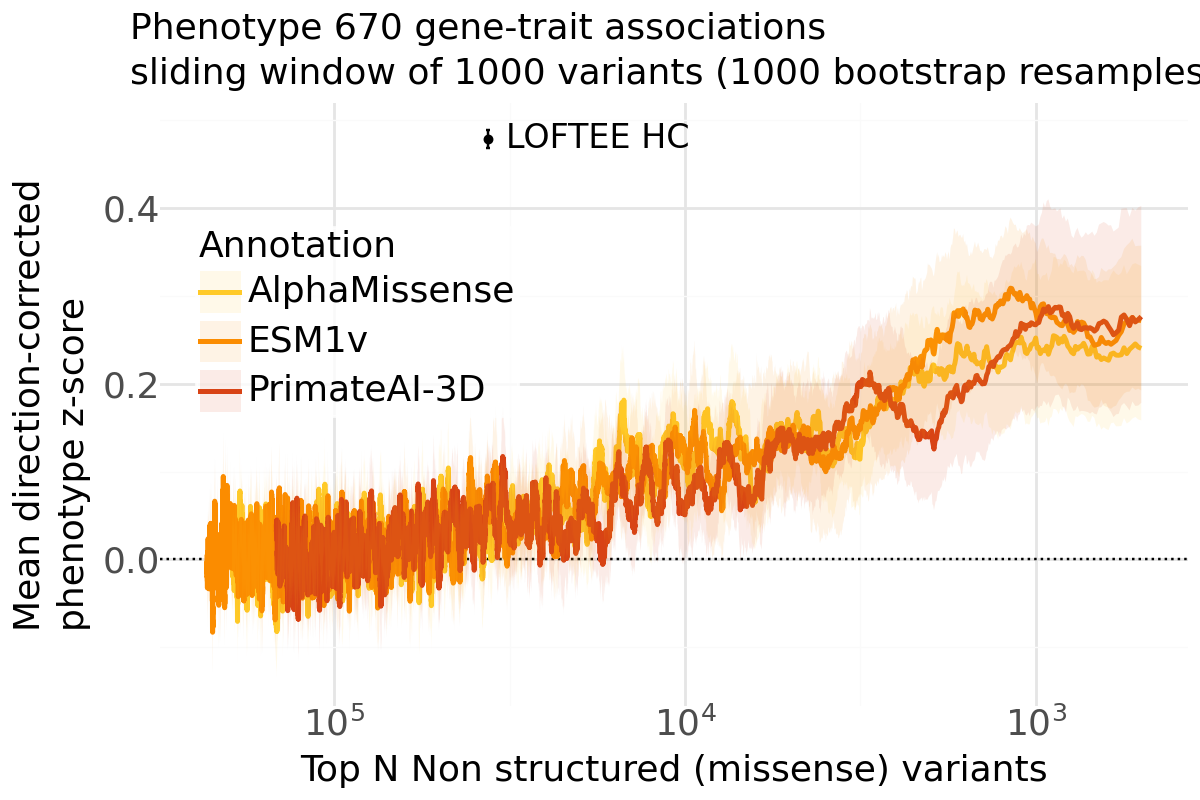

In [ ]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis (same style as odds ratio plot)
max_rank = zscore_binned['bin_center'].max()
min_rank = zscore_binned['bin_center'].min()
start_exp = int(np.floor(np.log10(1/max_rank)))
end_exp = int(np.ceil(np.log10(1/min_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        aes(x='log_bin_center_inv', y='mean_zscore')
    )
    + loftee_point
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Phenotype {gene_trait_df.shape[0]} gene-trait associations\nsliding window of {window_size} variants ({n_boot} bootstrap resamples)",
        y=f"Mean direction-corrected\nphenotype z-score",
        x=f"Top N missense variants",
        # x=f"Top N structured domain (missense) variants",
        # x=f"Top N LIP domain (missense) variants",
        # x=f"Top N Non structured (missense) variants",
        # x=f"Top N intronic variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.05, 0.7),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)